In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/v20-huggingface/train-v2.0.json


In [52]:
import json
import networkx as nx
import matplotlib.pyplot as plt


In [53]:
file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]


In [54]:
G = nx.DiGraph()


In [55]:
max_articles = 2

In [56]:
for article in data[:max_articles]:
    title = article["title"]
    G.add_node(title, type="Article")

    for para in article["paragraphs"]:
        context = para["context"][:80] + "..."  
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")

        for qa in para["qas"]:
            question = qa["question"]
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")

            if not qa["is_impossible"]:
                for ans in qa["answers"]:
                    answer = ans["text"]
                    G.add_node(answer, type="Answer")
                    G.add_edge(question, answer, relation="answered_by")
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")


plt.figure(figsize=(180, 120))
pos = nx.spring_layout(G, k=0.3)
colors = [ 
    "lightblue" if G.nodes[n]["type"] == "Article"
    else "lightgreen" if G.nodes[n]["type"] == "Context"
    else "lightyellow" if G.nodes[n]["type"] == "Question"
    else "lightcoral" for n in G.nodes
]


<Figure size 18000x12000 with 0 Axes>

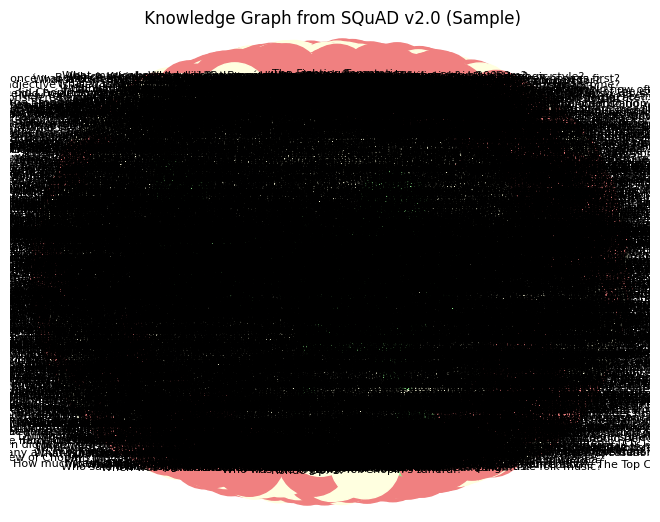

In [57]:
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2500, font_size=8, edge_color="gray")
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title(" Knowledge Graph from SQuAD v2.0 (Sample)")
plt.axis("off")
plt.show()

/tmp/ipykernel_35/792947770.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


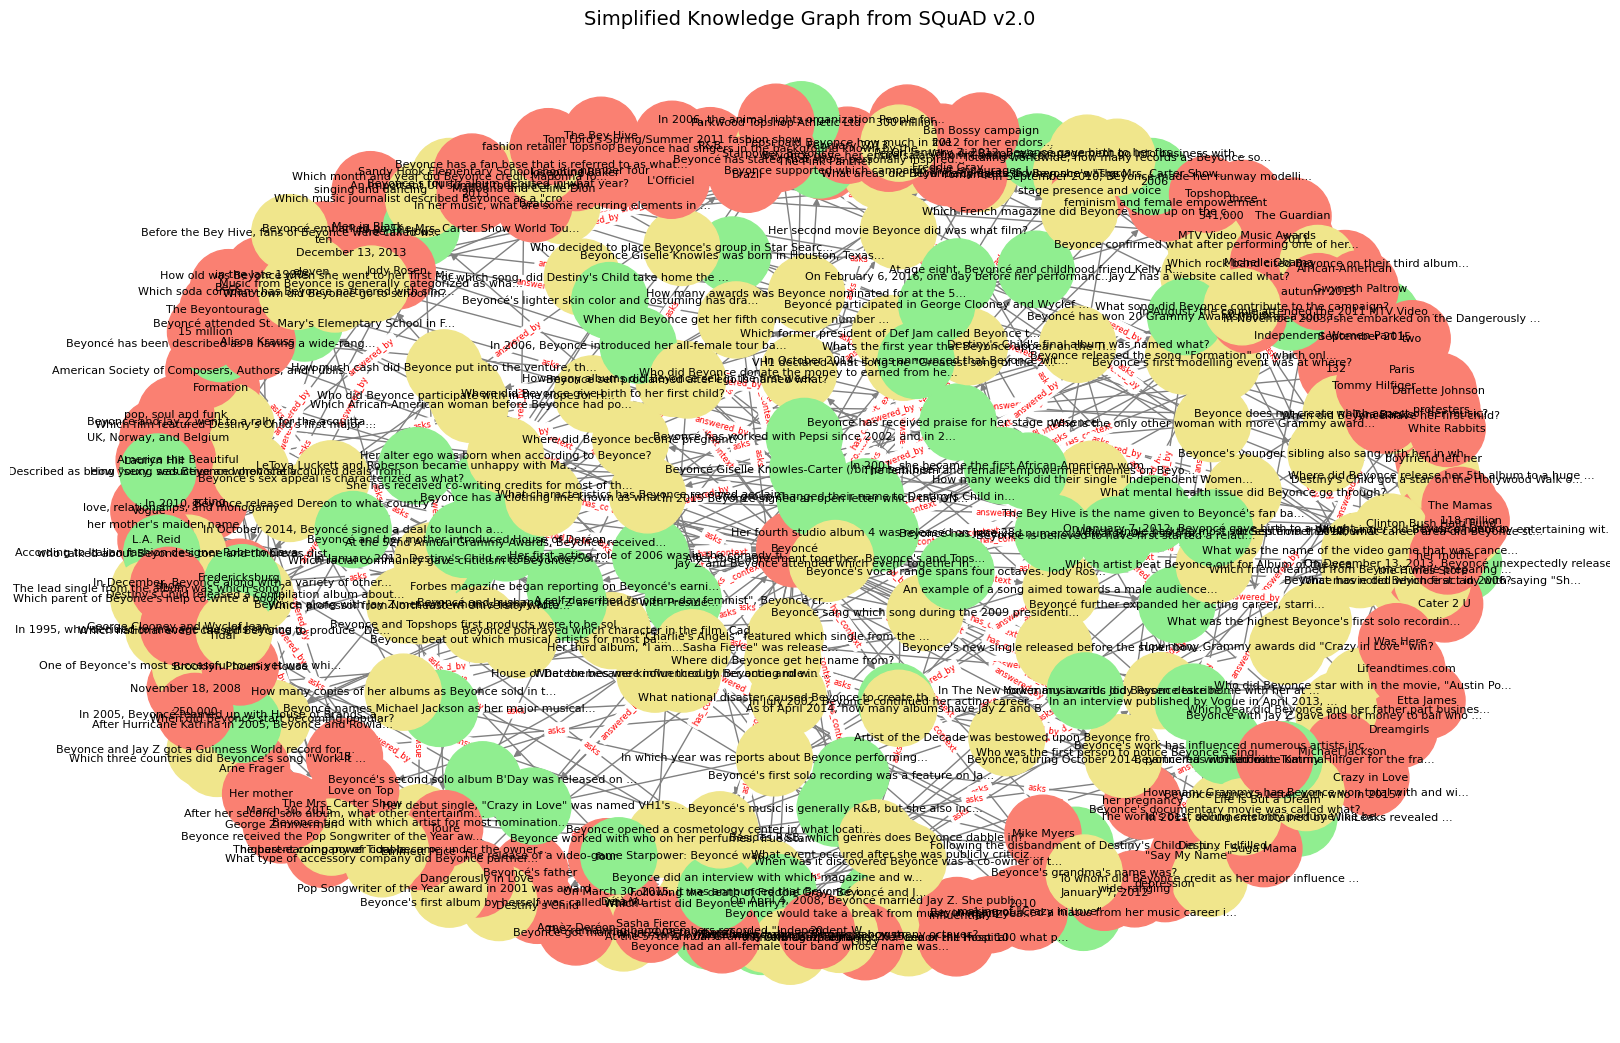

In [58]:

import json
import networkx as nx
import matplotlib.pyplot as plt


def truncate(text, length=50):
    return text[:length] + "..." if len(text) > length else text


file_path = "/kaggle/input/v20-huggingface/train-v2.0.json" 
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]


G = nx.DiGraph()


max_articles = 1
max_qas = 2


for article in data[:max_articles]:
    title = truncate(article["title"], 30)
    G.add_node(title, type="Article")

    for para in article["paragraphs"]:
        context = truncate(para["context"])
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")

        for qa in para["qas"][:max_qas]:
            question = truncate(qa["question"])
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")

            if not qa["is_impossible"]:
                for ans in qa["answers"][:1]:  # only show 1 answer
                    answer = truncate(ans["text"])
                    G.add_node(answer, type="Answer")
                    G.add_edge(question, answer, relation="answered_by")
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")


plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G, k=0.6, seed=42)

colors = [
    "skyblue" if G.nodes[n]["type"] == "Article"
    else "lightgreen" if G.nodes[n]["type"] == "Context"
    else "khaki" if G.nodes[n]["type"] == "Question"
    else "salmon" for n in G.nodes
]


nx.draw(G, pos, with_labels=True, node_color=colors, node_size=3000, font_size=8, edge_color="gray")
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=6)


plt.title("Simplified Knowledge Graph from SQuAD v2.0", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


/tmp/ipykernel_35/3631116390.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


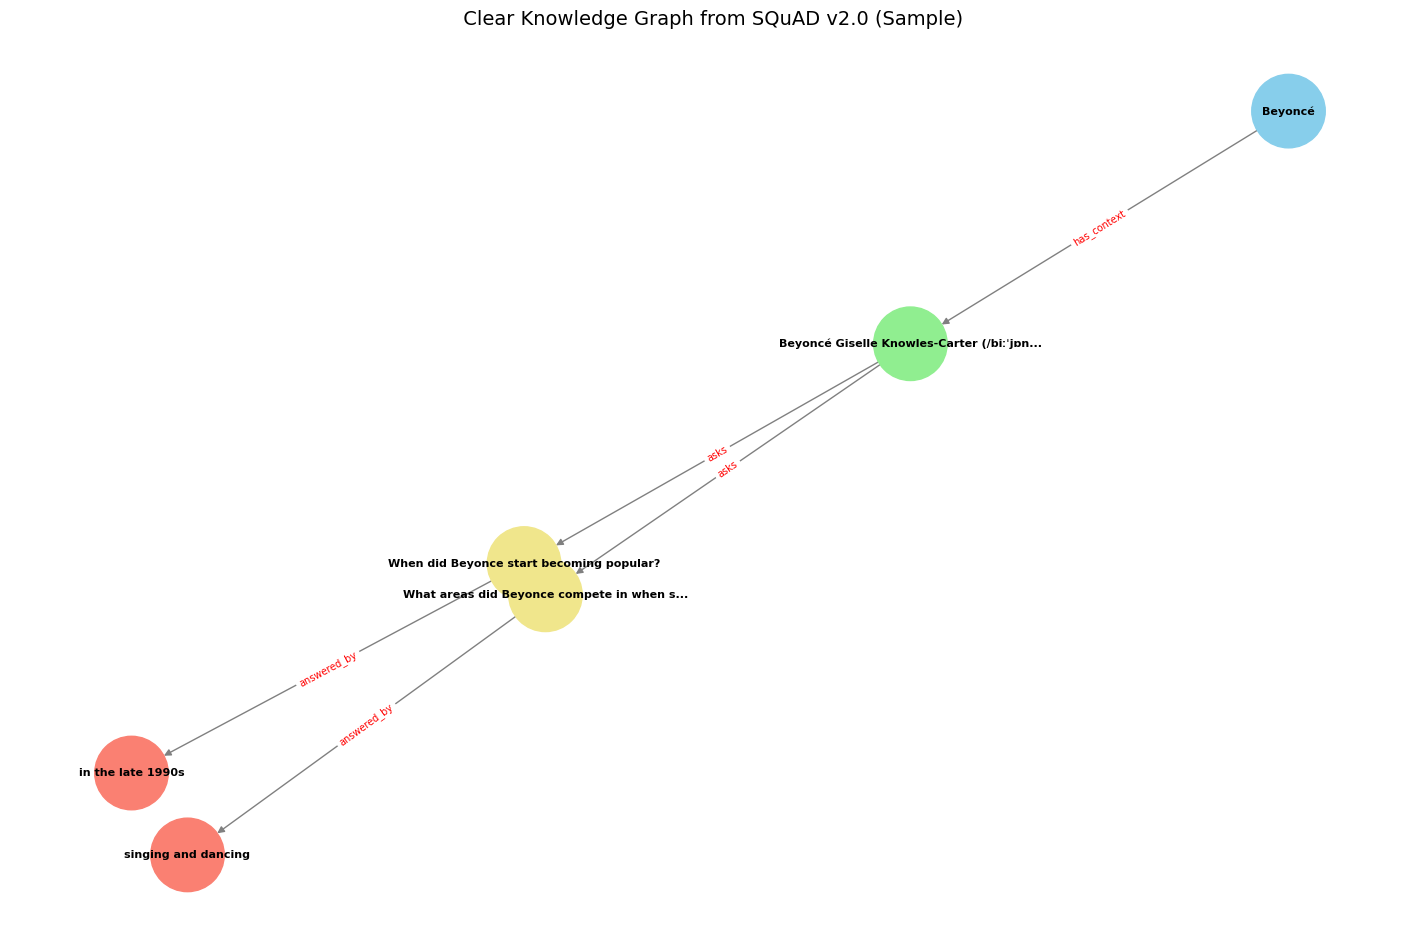

In [59]:

import json
import networkx as nx
import matplotlib.pyplot as plt


def truncate(text, length=40):
    return text[:length] + "..." if len(text) > length else text

file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"  
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]


G = nx.DiGraph()


max_articles = 1

max_qas = 2


for article in data[:max_articles]:
    title = truncate(article["title"])
    G.add_node(title, type="Article")

    for para in article["paragraphs"][:max_paragraphs]:
        context = truncate(para["context"])
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")

        for qa in para["qas"][:max_qas]:
            question = truncate(qa["question"])
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")

            if not qa["is_impossible"]:
                for ans in qa["answers"][:max_answers]:
                    answer = truncate(ans["text"])
                    G.add_node(answer, type="Answer")
                    G.add_edge(question, answer, relation="answered_by")
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")


plt.figure(figsize=(14, 9))
pos = nx.kamada_kawai_layout(G)  # Better spacing layout


color_map = {
    "Article": "skyblue",
    "Context": "lightgreen",
    "Question": "khaki",
    "Answer": "salmon"
}
node_colors = [color_map.get(G.nodes[n]["type"], "lightgray") for n in G.nodes]


nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2800, font_size=8, font_weight="bold", edge_color="gray")
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", font_size=7)

plt.title(" Clear Knowledge Graph from SQuAD v2.0 (Sample)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


Full Graph created: 214334 nodes and 279558 edges
 Sample Subgraph created with 10 QA pairs.


/tmp/ipykernel_35/2103466356.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


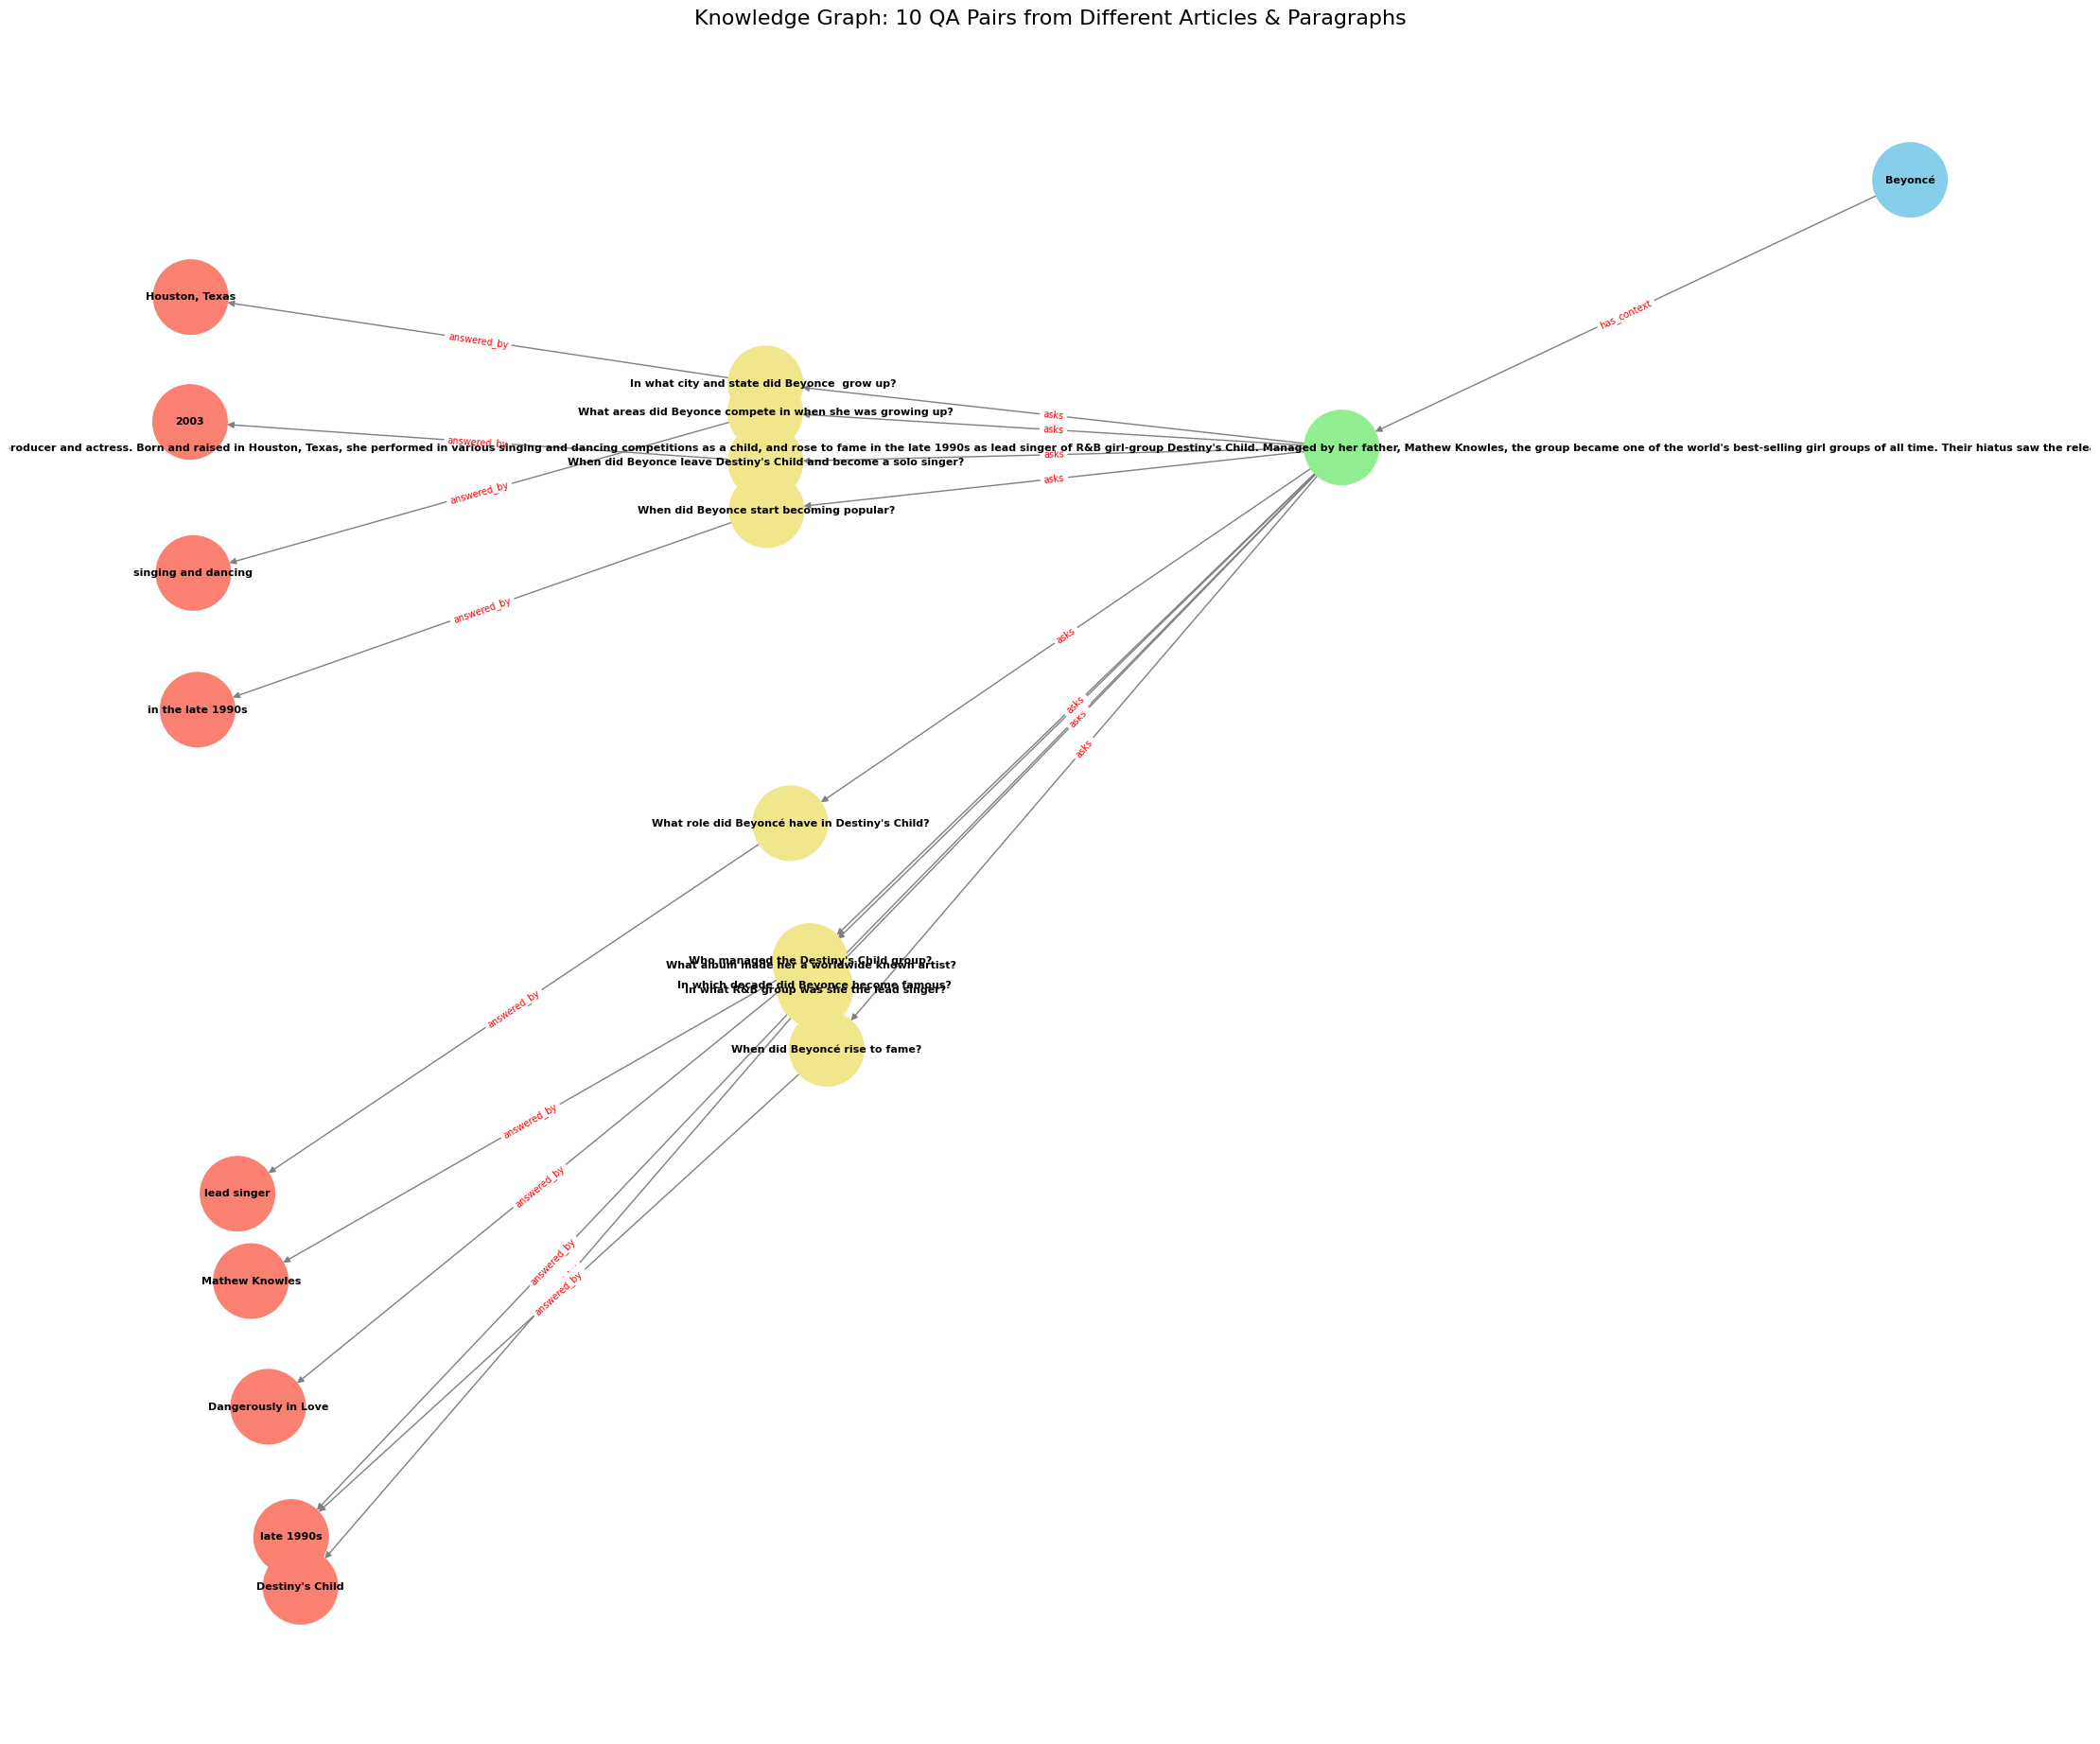

In [60]:

import json
import networkx as nx
import matplotlib.pyplot as plt


file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

full_graph = nx.DiGraph()

for article in data:
    title = article["title"]
    full_graph.add_node(title, type="Article")
    for para in article["paragraphs"]:
        context = para["context"]
        full_graph.add_node(context, type="Context")
        full_graph.add_edge(title, context, relation="has_context")
        for qa in para["qas"]:
            question = qa["question"]
            full_graph.add_node(question, type="Question")
            full_graph.add_edge(context, question, relation="asks")
            if not qa["is_impossible"]:
                for ans in qa["answers"]:
                    answer = ans["text"]
                    full_graph.add_node(answer, type="Answer")
                    full_graph.add_edge(question, answer, relation="answered_by")
            else:
                full_graph.add_node("No Answer", type="Answer")
                full_graph.add_edge(question, "No Answer", relation="answered_by")

print(f"Full Graph created: {len(full_graph.nodes)} nodes and {len(full_graph.edges)} edges")


sample_graph = nx.DiGraph()
qa_count = 0

for article in data:
    title = article["title"]
    for para in article["paragraphs"]:
        context = para["context"]
        for qa in para["qas"]:
            if qa_count >= 10:
                break
            question = qa["question"]
            if not qa["is_impossible"]:
                answer = qa["answers"][0]["text"] if qa["answers"] else "No Answer"
            else:
                answer = "No Answer"

            # Add nodes/edges to sample_graph
            sample_graph.add_node(title, type="Article")
            sample_graph.add_node(context, type="Context")
            sample_graph.add_node(question, type="Question")
            sample_graph.add_node(answer, type="Answer")

            sample_graph.add_edge(title, context, relation="has_context")
            sample_graph.add_edge(context, question, relation="asks")
            sample_graph.add_edge(question, answer, relation="answered_by")

            qa_count += 1
        if qa_count >= 10:
            break
    if qa_count >= 10:
        break

print(f" Sample Subgraph created with {qa_count} QA pairs.")


plt.figure(figsize=(22, 18))
pos = nx.kamada_kawai_layout(sample_graph)


color_map = {
    "Article": "skyblue",
    "Context": "lightgreen",
    "Question": "khaki",
    "Answer": "salmon"
}
node_colors = [color_map[sample_graph.nodes[n]["type"]] for n in sample_graph.nodes]


nx.draw(sample_graph, pos, with_labels=True, node_color=node_colors,
        node_size=3200, font_size=8, edge_color="gray", font_weight="bold")
edge_labels = nx.get_edge_attributes(sample_graph, "relation")
nx.draw_networkx_edge_labels(sample_graph, pos, edge_labels=edge_labels,
                             font_color="red", font_size=7)

plt.title("Knowledge Graph: 10 QA Pairs from Different Articles & Paragraphs", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


In [61]:
import json
import networkx as nx
from sklearn.metrics import accuracy_score

file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]


G = nx.DiGraph()
qa_pairs = []  

for article in data:
    title = article["title"]
    G.add_node(title, type="Article")

    for para in article["paragraphs"]:
        context = para["context"]
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")

        for qa in para["qas"]:
            question = qa["question"]
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")

            if not qa["is_impossible"]:
                answers = [ans["text"] for ans in qa["answers"]]
                best_answer = answers[0] if answers else "No Answer"
                G.add_node(best_answer, type="Answer")
                G.add_edge(question, best_answer, relation="answered_by")
                qa_pairs.append((question, best_answer))
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")
                qa_pairs.append((question, "No Answer"))

true_answers = []
pred_answers = []


for question, true_answer in qa_pairs[:100]:
    true_answers.append(true_answer)

    
    found = False
    for neighbor in G.successors(question):
        if G[question][neighbor]["relation"] == "answered_by":
            pred_answers.append(neighbor)
            found = True
            break
    if not found:
        pred_answers.append("No Answer")


correct = sum([1 for true, pred in zip(true_answers, pred_answers) if true.strip().lower() == pred.strip().lower()])
accuracy = correct / len(true_answers)

print(f"Evaluated {len(true_answers)} QA pairs")
print(f" Accuracy of Knowledge Graph QA: {accuracy:.2%}")



Evaluated 100 QA pairs
 Accuracy of Knowledge Graph QA: 100.00%


In [62]:
import json
import networkx as nx
import string
from collections import Counter


def normalize_answer(s):
    def remove_articles(text):
        return ' '.join(w for w in text.split() if w.lower() not in ['a', 'an', 'the'])
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in string.punctuation)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))


def exact_match_score(prediction, ground_truth):
    return normalize_answer(prediction) == normalize_answer(ground_truth)


def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)
    if num_same == 0:
        return 0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)


file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]


G = nx.DiGraph()
qa_pairs = []

for article in data:
    title = article["title"]
    G.add_node(title, type="Article")

    for para in article["paragraphs"]:
        context = para["context"]
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")

        for qa in para["qas"]:
            question = qa["question"]
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")

            if not qa["is_impossible"]:
                answers = [ans["text"] for ans in qa["answers"]]
                best_answer = answers[0] if answers else "No Answer"
                G.add_node(best_answer, type="Answer")
                G.add_edge(question, best_answer, relation="answered_by")
                qa_pairs.append((question, best_answer))
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")
                qa_pairs.append((question, "No Answer"))


em_total, f1_total = 0, 0
sample_outputs = []

for i, (question, true_answer) in enumerate(qa_pairs[:100]):
    pred_answer = "No Answer"
    for neighbor in G.successors(question):
        if G[question][neighbor]["relation"] == "answered_by":
            pred_answer = neighbor
            break

    em = exact_match_score(pred_answer, true_answer)
    f1 = f1_score(pred_answer, true_answer)

    em_total += em
    f1_total += f1

    if i < 10:  
        sample_outputs.append({
            "Question": question,
            "True Answer": true_answer,
            "Predicted Answer": pred_answer,
            "EM": em,
            "F1": round(f1, 2)
        })


print(" Sample QA Predictions (first 10 examples):\\n")
for i, sample in enumerate(sample_outputs, 1):
    print(f" * Example {i}")
    print(f"Question         : {sample['Question']}")
    print(f"True Answer      : {sample['True Answer']}")
    print(f"Predicted Answer : {sample['Predicted Answer']}")
    print(f"Exact Match      : {sample['EM']}")
    print(f"F1 Score         : {sample['F1']}")
    print("-" * 60)


print(f" Evaluated 100 QA pairs")
print(f" Exact Match Score : {em_total/100:.2%}")
print(f"F1 Score          : {f1_total/100:.2%}")


 Sample QA Predictions (first 10 examples):\n
 * Example 1
Question         : When did Beyonce start becoming popular?
True Answer      : in the late 1990s
Predicted Answer : in the late 1990s
Exact Match      : True
F1 Score         : 1.0
------------------------------------------------------------
 * Example 2
Question         : What areas did Beyonce compete in when she was growing up?
True Answer      : singing and dancing
Predicted Answer : singing and dancing
Exact Match      : True
F1 Score         : 1.0
------------------------------------------------------------
 * Example 3
Question         : When did Beyonce leave Destiny's Child and become a solo singer?
True Answer      : 2003
Predicted Answer : 2003
Exact Match      : True
F1 Score         : 1.0
------------------------------------------------------------
 * Example 4
Question         : In what city and state did Beyonce  grow up? 
True Answer      : Houston, Texas
Predicted Answer : Houston, Texas
Exact Match      : True

In [63]:
import json
import networkx as nx
import string
from sklearn.metrics import accuracy_score
from collections import Counter


def normalize_answer(s):
    """Lower text, remove punctuation, articles and extra whitespace."""
    def remove_articles(text):
        return ' '.join(w for w in text.split() if w.lower() not in ['a', 'an', 'the'])
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in string.punctuation)
    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))
    
def exact_match_score(prediction, ground_truth):
    return normalize_answer(prediction) == normalize_answer(ground_truth)


def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())

    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return int(pred_tokens == gt_tokens)
    if num_same == 0:
        return 0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)


file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

G = nx.DiGraph()
qa_pairs = []

for article in data:
    title = article["title"]
    G.add_node(title, type="Article")
    for para in article["paragraphs"]:
        context = para["context"]
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")
        for qa in para["qas"]:
            question = qa["question"]
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")
            if not qa["is_impossible"]:
                answers = [ans["text"] for ans in qa["answers"]]
                best_answer = answers[0] if answers else "No Answer"
                G.add_node(best_answer, type="Answer")
                G.add_edge(question, best_answer, relation="answered_by")
                qa_pairs.append((question, best_answer))
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")
                qa_pairs.append((question, "No Answer"))


em_total = 0
f1_total = 0
n = 100 

for question, true_answer in qa_pairs[:n]:
# predicted answer for kg
    pred_answer = "No Answer"
    for neighbor in G.successors(question):
        if G[question][neighbor]["relation"] == "answered_by":
            pred_answer = neighbor
            break

    em = exact_match_score(pred_answer, true_answer)
    f1 = f1_score(pred_answer, true_answer)

    em_total += em
    f1_total += f1

print(f" Evaluated {n} QA pairs")
print(f" Exact Match (EM): {em_total/n:.2%}")
print(f" F1 Score: {f1_total/n:.2%}")


 Evaluated 100 QA pairs
 Exact Match (EM): 100.00%
 F1 Score: 100.00%


In [64]:

import json
import networkx as nx


file_path = "/kaggle/input/v20-huggingface/train-v2.0.json"  
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

G = nx.DiGraph()

for article in data:
    title = article["title"]
    G.add_node(title, type="Article")

    for para in article["paragraphs"]:
        context = para["context"]
        G.add_node(context, type="Context")
        G.add_edge(title, context, relation="has_context")

        for qa in para["qas"]:
            question = qa["question"]
            G.add_node(question, type="Question")
            G.add_edge(context, question, relation="asks")

            if not qa["is_impossible"]:
                answers = [ans["text"] for ans in qa["answers"]]
                if answers:
                    answer = answers[0]
                    G.add_node(answer, type="Answer")
                    G.add_edge(question, answer, relation="answered_by")
            else:
                G.add_node("No Answer", type="Answer")
                G.add_edge(question, "No Answer", relation="answered_by")

print(f" Knowledge Graph created with {len(G.nodes)} nodes and {len(G.edges)} edges.\n")


short_qa = []  
medium_qa = []  

for node in G.nodes:
    if G.nodes[node].get("type") == "Question":
        for neighbor in G.successors(node):
            if G[node][neighbor].get("relation") == "answered_by":
                question = node.strip()
                answer = neighbor.strip()
                word_count = len(answer.split())
                char_count = len(answer)

                if 1 <= word_count <= 5:
                    short_qa.append((question, answer))
                elif 6 <= word_count <= 40 and char_count <= 200:
                    medium_qa.append((question, answer))


print("** Short QA Pairs (1–5 word answers):\n")
for i, (q, a) in enumerate(short_qa[:5], 1):
    print(f"* Q{i}: {q}")
    print(f" -->  A{i}: {a}\n")

print("\n** Medium QA Pairs (6–40 words or ≤200 chars):\n")
for i, (q, a) in enumerate(medium_qa[:5], 1):
    print(f" * Q{i}: {q}")
    print(f" -->  A{i}: {a}\n")


 Knowledge Graph created with 214334 nodes and 279558 edges.

** Short QA Pairs (1–5 word answers):

* Q1: When did Beyonce start becoming popular?
 -->  A1: in the late 1990s

* Q2: What areas did Beyonce compete in when she was growing up?
 -->  A2: singing and dancing

* Q3: When did Beyonce leave Destiny's Child and become a solo singer?
 -->  A3: 2003

* Q4: In what city and state did Beyonce  grow up?
 -->  A4: Houston, Texas

* Q5: In which decade did Beyonce become famous?
 -->  A5: late 1990s


** Medium QA Pairs (6–40 words or ≤200 chars):

 * Q1: A fight scene from the movie, Obsessed, won which award for Beyonce?
 -->  A1: MTV Movie Award for Best Fight

 * Q2: Where did Beyoncé perform on January 20, 2009?
 -->  A2: the First Couple's first inaugural ball.

 * Q3: Who awarded Beyonce and award for writing?
 -->  A3: New York Association of Black Journalists

 * Q4: Where was Blue Ivy born?
 -->  A4: Lenox Hill Hospital in New York.

 * Q5: What was the name of Beyoncé's to